# Práctica 1 Aprendizaje Automático: Predicción de Subscripción a un Producto Bancario

**Miembros del equipo:**
    Jose Luis Mejía 1: (NIA:100472712)
    Mireya Luque 2: (NIA:100495927)

____________________________________________________________________________________________________

**Uso de IA generativa**

Durante la realización de esta práctica se utilizó IA generativa como herramienta de apoyo. Donde su uso principal fue:

- Ayudar a redactar explicaciones de celdas y conclusiones,
- Sugerir posibles implementaciones de algunas partes del código,
- Revisar errores de ejecución y proponer correcciones,
- Ayudar a estructurar el notebook y el script de despliegue en Streamlit.

En todo momento, amnbos miembros del grupo revisaron manualmente todas las propuestas antes de incorporarlas. Algunas respuestas de la IA no se ajustaban del todo al enunciado o a la estructura concreta del proyecto, por lo que fue necesario modificarlas, simplificarlas o descartarlas.

Por ende, la IA se empleó como apoyo técnico y de redacción.

In [50]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [51]:
### IMPORTS PARA EL NOTEBOOK


### SKLEARN
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

from pathlib import Path



import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import time
import warnings

## Carga inicial de datos y configuración de reproducibilidad

En este bloque se fija una **semilla aleatoria** usando un NIA del equipo (**100495927**) con `np.random.seed(NIA)`.  
Esto garantiza que cualquier proceso que dependa de aleatoriedad (por ejemplo, particiones train test o validación cruzada) produzca los mismos resultados cada vez que se ejecute el notebook.

A continuación, se define la ruta del archivo `bank_09.pkl` y se carga el dataset con `pd.read_pickle`.

Finalmente, se muestra:
- La **dimensión del dataset** (número de filas y columnas) para tener una visión general.
- Las **primeras filas** con `head()` para comprobar que la carga se ha realizado correctamente y ver un ejemplo del contenido.

In [52]:
#Fijamos la semilla con un NIA del equipo
NIA = 100495927
np.random.seed(NIA)

#Cargamos los datos
ruta_archivo = 'Datos/bank_09.pkl'
df = pd.read_pickle(ruta_archivo)

#Mostramos la información
print("Dimensiones del dataset:", df.shape)
display(df.head())

Dimensiones del dataset: (11000, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## EDA simplificado: estructura, tipos de variables y calidad de datos

En este bloque se realiza un **EDA simplificado** para obtener una visión general del dataset y detectar posibles problemas de calidad de datos que afecten al preprocesamiento y al modelado.

### 1. Instancias y variables
Se imprime el número de **filas** (instancias) y **columnas** (variables) del dataset usando `df.shape`. Esto permite conocer el tamaño del conjunto de datos con el que se va a trabajar.

### 2. Tipos de variables
Se diferencian tres grupos principales:
- **Numéricas**: columnas de tipo `int64` o `float64`.
- **Categóricas nominales**: columnas categóricas sin orden natural.
- **Variables ordinales o potencialmente ordenadas**: variables que, por su significado, pueden tener un orden lógico, como `education`, `month` o `day_of_week` si están presentes.

Aunque algunas de estas variables pueden interpretarse como ordinales, en esta práctica no se va a aplicar por defecto una codificación ordinal específica. Se dejan identificadas en el EDA, pero en el modelado se seguirán tratando como categóricas para no introducir supuestos adicionales sin validación previa.

### 3. Valores faltantes
Se calcula cuántos valores nulos hay en cada columna con `df.isnull().sum()`. Después se filtran solo aquellas columnas que realmente tengan valores faltantes. Si no hay columnas con nulos, se indica explícitamente.

### 4. Columnas constantes
Se detectan columnas con **un único valor** calculando el número de valores únicos con `nunique()`. Estas columnas no aportan capacidad predictiva.

### 5. Posibles columnas de ID
Se comprueba si existen columnas que puedan actuar como identificadores:
- por nombre, buscando columnas cuyo nombre contenga `id`
- por cardinalidad, detectando columnas con una proporción de valores únicos extremadamente alta

Si aparecieran, habría que valorar su eliminación, ya que una columna ID no suele aportar información útil para generalizar.

### 6. Alta cardinalidad en variables categóricas
Se identifican variables categóricas con **más de 10 valores únicos**. Esto es relevante porque puede aumentar mucho la dimensionalidad al aplicar `OneHotEncoder`.

### 7. Tipo de problema y balanceo de la variable objetivo
Se confirma que el problema es de **clasificación binaria**, ya que la variable objetivo es `deposit`. Además, se calcula el porcentaje de cada clase para comprobar si el dataset está balanceado o presenta cierto desbalanceo.

### 8. Análisis particular de `pdays` y decisión de preprocesado
La variable `pdays` representa el número de días desde el último contacto en una campaña anterior, pero el valor `-1` no significa una cantidad real de días, sino **sin contacto previo o valor desconocido**. Por tanto, no conviene tratarla directamente como una variable numérica estándar.

Para evitar mezclar una magnitud temporal real con un código especial:
- se crea una variable binaria `contactado_antes`, que vale 1 si `pdays != -1` y 0 en caso contrario
- se elimina la columna original `pdays`

De este modo, el preprocesado de esta variable queda resuelto ya en esta sección y además la interpretación posterior del modelo será más coherente.

In [53]:
print("--- 1. INSTANCIAS Y VARIABLES ---")
print(f"Número de instancias (filas): {df.shape[0]}")
print(f"Número de variables (columnas): {df.shape[1]}")

print("\n--- 2. TIPOS DE VARIABLES ---")
numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categoricas = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

posibles_ordinales = [col for col in ["education", "month", "day_of_week"] if col in categoricas]
categoricas_nominales = [col for col in categoricas if col not in posibles_ordinales]

print(f"Variables numéricas ({len(numericas)}): {numericas}")
print(f"Variables categóricas nominales ({len(categoricas_nominales)}): {categoricas_nominales}")
print(f"Variables ordinales o potencialmente ordenadas ({len(posibles_ordinales)}): {posibles_ordinales if posibles_ordinales else 'Ninguna'}")

print("\n--- 3. VALORES FALTANTES ---")
nulos = df.isnull().sum()
nulos_reales = nulos[nulos > 0]
if len(nulos_reales) > 0:
    print(nulos_reales)
else:
    print("No hay valores faltantes en ninguna columna.")

print("\n--- 4. COLUMNAS CONSTANTES ---")
constantes = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Columnas constantes o con un solo valor: {constantes if constantes else 'Ninguna'}")

print("\n--- 5. POSIBLES COLUMNAS DE ID ---")
columnas_id_por_nombre = [col for col in df.columns if "id" in col.lower()]

ratio_unicos = (
    df.drop(columns=["deposit"], errors="ignore").nunique() / len(df)
)
columnas_id_por_cardinalidad = ratio_unicos[ratio_unicos > 0.98].index.tolist()

columnas_id = sorted(set(columnas_id_por_nombre + columnas_id_por_cardinalidad))
print(f"Posibles columnas ID detectadas: {columnas_id if columnas_id else 'Ninguna'}")

print("\n--- 6. ALTA CARDINALIDAD EN CATEGÓRICAS (>10 valores únicos) ---")
alta_cardinalidad = [col for col in categoricas if df[col].nunique() > 10]
if alta_cardinalidad:
    for col in alta_cardinalidad:
        print(f"- {col}: {df[col].nunique()} valores únicos")
else:
    print("No hay variables categóricas con alta cardinalidad.")

print("\n--- 7. PROBLEMA Y BALANCEO DE LA VARIABLE OBJETIVO ---")
print("Problema: Clasificación binaria (predecir si se suscribe o no el depósito)")
balanceo = df["deposit"].value_counts(normalize=True) * 100
print("Balanceo de clases en 'deposit' (%):")
print(balanceo.round(2))

print("\n--- 8. ANÁLISIS PARTICULAR DE 'pdays' Y PREPROCESADO ---")
if "pdays" in df.columns:
    print("Descripción de 'pdays':")
    print(df["pdays"].describe())

    print("\nTop 5 valores más comunes en 'pdays':")
    print(df["pdays"].value_counts().head())

    porcentaje_sin_contacto = round((df["pdays"] == -1).mean() * 100, 2)
    print(f"\nPorcentaje de clientes sin contacto previo o desconocido (pdays = -1): {porcentaje_sin_contacto}%")

    df["contactado_antes"] = (df["pdays"] != -1).astype(int)
    df = df.drop(columns=["pdays"])

    print("\nDecisión de preprocesado aplicada:")
    print("- Se crea la variable binaria 'contactado_antes'")
    print("- Se elimina la variable original 'pdays' para no mezclar un código especial (-1) con una cantidad real de días")
    print(f"- Número de variables tras el preprocesado de 'pdays': {df.shape[1]}")

elif "contactado_antes" in df.columns:
    print("El preprocesado de 'pdays' ya estaba aplicado previamente.")
    print("La variable 'contactado_antes' ya existe y 'pdays' ya no está en el dataset.")

else:
    print("No se encuentra la columna 'pdays' en el dataset.")

--- 1. INSTANCIAS Y VARIABLES ---
Número de instancias (filas): 11000
Número de variables (columnas): 17

--- 2. TIPOS DE VARIABLES ---
Variables numéricas (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Variables categóricas nominales (8): ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome', 'deposit']
Variables ordinales o potencialmente ordenadas (2): ['education', 'month']

--- 3. VALORES FALTANTES ---
job         97
marital    282
dtype: int64

--- 4. COLUMNAS CONSTANTES ---
Columnas constantes o con un solo valor: Ninguna

--- 5. POSIBLES COLUMNAS DE ID ---
Posibles columnas ID detectadas: Ninguna

--- 6. ALTA CARDINALIDAD EN CATEGÓRICAS (>10 valores únicos) ---
- job: 12 valores únicos
- month: 12 valores únicos

--- 7. PROBLEMA Y BALANCEO DE LA VARIABLE OBJETIVO ---
Problema: Clasificación binaria (predecir si se suscribe o no el depósito)
Balanceo de clases en 'deposit' (%):
deposit
no     52.55
yes    47.45
Name: proportion, dtyp

# Estrategia de evaluación del modelo

En esta sección definimos cómo vamos a evaluar los modelos durante toda la práctica. La idea principal es **no usar el conjunto de test para tomar decisiones**, sino reservarlo para el final. Así evitamos obtener una estimación demasiado optimista del rendimiento.

Según el enunciado, usaremos dos niveles de evaluación:

## 1) Evaluación externa (outer): Holdout
Vamos a hacer una partición fija del dataset en dos partes:
- **Train (entrenamiento): 2/3 de los datos**
- **Test (prueba): 1/3 de los datos**

El conjunto **test** se guardará y **no se tocará durante el desarrollo**. Solo se utilizará una vez al final, cuando ya se haya elegido el mejor enfoque.

## 2) Evaluación interna (inner): validación cruzada sobre train
Para comparar modelos y para ajustar hiperparámetros, trabajaremos únicamente con el conjunto de entrenamiento usando **validación cruzada estratificada**.

Esto nos permite:
- comparar modelos de forma más estable
- elegir hiperparámetros sin usar el test
- mantener la proporción de clases en cada partición

## Métrica principal
Como el objetivo `deposit` define un problema de **clasificación binaria**, utilizaremos **Accuracy** como métrica principal durante la práctica.

La elección de Accuracy es razonable porque:
- el problema es de clasificación binaria
- el balanceo observado en el EDA no es extremo
- la validación se hará de forma **estratificada**, lo que ayuda a mantener proporciones similares de clases en cada fold

Aun así, Accuracy no cuenta toda la historia. Por eso, cuando evaluemos el modelo final en el conjunto **test**, complementaremos el análisis con la **matriz de confusión**, para entender mejor qué tipo de errores comete el modelo.

## División Train-Test (Holdout)

En este bloque se divide el dataset en dos conjuntos: **entrenamiento (train)** y **prueba (test)** usando una estrategia de tipo *holdout*.

La partición se hace con esta proporción:
- **2/3** de los datos para **train**
- **1/3** de los datos para **test**

El conjunto **train** se utilizará durante casi toda la práctica (comparar modelos, ajustar hiperparámetros, etc.).  
El conjunto **test** se reservará para el final, para evaluar el rendimiento del modelo definitivo con datos que no se han usado durante el desarrollo.

Además, se aplica **estratificación** para que la variable objetivo (por ejemplo `deposit`) mantenga aproximadamente el mismo porcentaje de clases en train y en test. Esto es importante para que ambos conjuntos sean representativos, especialmente si las clases están desbalanceadas.

In [54]:
X = df.drop("deposit", axis=1)
y = df["deposit"].map({"no": 0, "yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (7370, 16)
Test size: (3630, 16)


## Evaluación interna (inner)

Para comparar modelos y ajustar hiperparámetros vamos a trabajar únicamente con el conjunto **train** usando validación cruzada.

En concreto, usaremos **validación cruzada estratificada** (Stratified K-Fold) con **3 particiones** como se nos recomienda, para que en cada fold se mantenga aproximadamente la proporción de clases de `deposit`.  
Esto nos permite comparar alternativas y hacer HPO sin utilizar el conjunto **test**, que se reservará para la evaluación final (outer).

In [55]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=100495927
)

# Entrenamiento y Evaluación de modelos

En esta fase vamos a entrenar y comparar **distintos algoritmos** de clasificación para realizar la predicción de si un cliente suscribirá o no el depósito.

## 1) K-Nearest Neighbors (KNN): Selección del mejor escalador

El algoritmo KNN se basa en medir distancias entre los clientes. Por ello, es fundamental **escalar** las variables numéricas para que el saldo en este caso no domine sobre otras variables. Para ello probaremos el modelo KNN con sus **hiperparámetros por defecto** y evaluaremos qué técnica de escalado nos da mejor resultado. 

Usaremos un `pipeline` para aplicar `OneHotEncoder` a las variables categóricas y probaremos los tres escaladores diferentes:
- StandardScaler
- MinMaxScaler
- RobustScaler


Mediremos tanto la métrica de *Accuracy* mediante **3-Fold CrossValidation** como el tiempo de ejecución para elegir la mejor alternativa

In [56]:
#Separamos las columnas numéricas y categóricas para el preprocesador
columnas_numericas = X_train.select_dtypes(include=['int32','int64', 'float64']).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

#Definimos los tres escaladores
escaladores = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

resultados_knn = []

print("--- EVALUACIÓN DE ESCALDORES CON KNN ---")
for nombre, scaler in escaladores.items():

    #1) Creamos el preprocesador de columnas
    preprocesador = ColumnTransformer(
        transformers=[
            ('num', scaler, columnas_numericas),
            ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
        ])
    
    #2) Creamos la pipeline con el modelo KNN por defecto
    pipeline_knn = Pipeline(steps=[
        ('preprocesamiento', preprocesador),
        ('modelo', KNeighborsClassifier())
    ])

    #3) Evaluamos con validación cruzada y medimos los tiempos
    start_time = time.time()
    cv_results = cross_validate(pipeline_knn, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

    tiempo_total = time.time() - start_time
    accuracy_media = cv_results['test_score'].mean()

    #4) Guardamos los resultados
    resultados_knn.append({
        'Escalador': nombre,
        'Accuracy Media': round(accuracy_media, 4),
        'Tiempo Total (s)': round(tiempo_total, 4)
    })

    #print(f"-> {nombre} | Accuracy: {accuracy_media:.4f} | Tiempo: {tiempo_total:.2f} segundos")

#Mostramos los resultados en un DataFrame 
df_resultados_knn = pd.DataFrame(resultados_knn)
display(df_resultados_knn)
    


--- EVALUACIÓN DE ESCALDORES CON KNN ---


,Escalador,Accuracy Media,Tiempo Total (s)
0,StandardScaler,0.8019,2.5159
1,MinMaxScaler,0.7332,2.0206
2,RobustScaler,0.7986,2.0416


El método que ha demostrado un mejor comportamiento para este conjunto de datos es el `StandardScaler`, ya que proporciona un rendimiento predictivo significativamente superior. Aunque su tiempo de ejecución es ligeramente mayor, la **mejora en el rendimiento** justifica plenamente su elección. En definitiva, este será el escalador que utilizaremos de aquí en adelante para todos los modelos que requieran un escalado de datos.

## 2) Evaluación de Árboles de Decisión y Modelo Baseline

Como hemos visto, ya hemos evaluado KNN con sus hiperparámetros por defecto. Ahora, evaluaremos un modelo de **Árboles de Decisión** (`DecisionTreeClassifier`) con sus valores por **omisión**. Además, entrenaremos un modelo trivial (`DummyClassifier`) que predice siempre la **clase mayoritaria**. Esto nos servirá como línea base para responder posteriormente a la pregunta de si nuestros algoritmos son mejores que un modelo *naive*.

A diferencia del algoritmo KNN, los árboles de decisión no son sensibles a la magnitud de las variables numéricas, por lo que no es estrictamente necesario aplicar el `StandardScaler`, aunque sí debemos codificar las variables categóricas con `OneHotEncoder`.

In [57]:
print("--- EVALUACIÓN DE ÁRBOLES DE DECISIÓN Y DUMMY ---")

#Preprocesador para variables categóricas y pasamos las numéricas tal cual
preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ])

#Definimos los modelos a evaluar
modelo_2a = {
    'Dummy Classifier (Baseline)': DummyClassifier(strategy='prior'),
    'Decision Tree (Por defecto)': DecisionTreeClassifier(random_state=NIA)
}

resultados_2a = []

#Evaluamos cada modelo con validación cruzada y medimos los tiempos en un for
for nombre, modelo in modelo_2a.items():

    #Creamos la pipeline
    pipeline = Pipeline(steps=[
        ('preprocesamiento', preprocessor_tree),
        ('clasificador', modelo)
    ])

    #Evaluamos con validación cruzada
    start_time = time.time()
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    tiempo_total = time.time() - start_time
    accuracy_media = cv_results['test_score'].mean()

    #Guardamos los resultados
    resultados_2a.append({
        'Modelo': nombre,
        'Accuracy Media': round(accuracy_media, 4),
        'Tiempo Total (s)': round(tiempo_total, 4)
    })

df_resumen_2a = pd.DataFrame(resultados_2a)
display(df_resumen_2a)

--- EVALUACIÓN DE ÁRBOLES DE DECISIÓN Y DUMMY ---


,Modelo,Accuracy Media,Tiempo Total (s)
0,Dummy Classifier (Baseline),0.5255,0.1460
1,Decision Tree (Por defecto),0.7887,0.2288


## 3) Árboles de Decisión poco profundos

Una de las grandes ventajas de los árboles de decisión frente a algoritmos como KNN es su **interpretabilidad**. Para entender cómo se toman las decisiones en este problema, vamos a entrenar un árbol limitando su profundidad máxima (`max_depth=3`).
**Limitando la profundidad** sacrificamos algo de exactitud predictiva, pero ganamos la capacidad de visualizar el árbol y extraer las reglas de negocio más importantes.

--- ENTRENAMIENTO Y VISUALIZACIÓN DE ÁRBOL POCO PROFUNDO ---


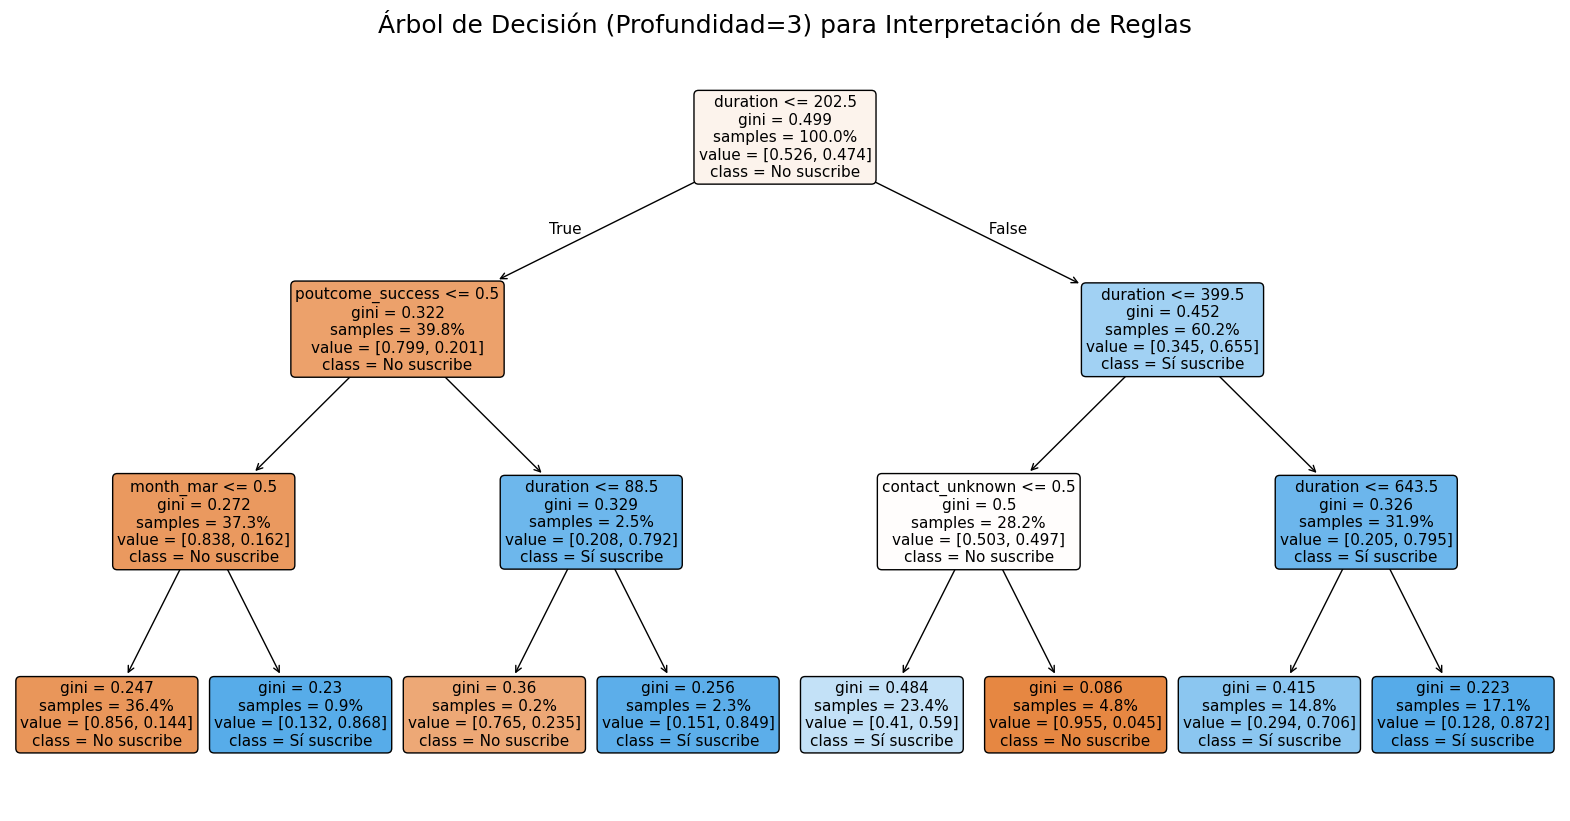

In [58]:
print("--- ENTRENAMIENTO Y VISUALIZACIÓN DE ÁRBOL POCO PROFUNDO ---")

#Definimos un árbol limitado a 3 niveles de profundidad
arbol_interpretable = DecisionTreeClassifier(max_depth=3, random_state=NIA)

#Creamos la pipeline usando el mismo preprocesador de árboles que antes
pipeline_interpretable = Pipeline(steps=[   
    ('preprocesamiento', preprocessor_tree),
    ('clasificador', arbol_interpretable)
])

#Entrenamos el modelo con todo el conjunto de X_train
#No usamos CV porque no estamos evaluando
pipeline_interpretable.fit(X_train, y_train)
preprocesador = pipeline_interpretable.named_steps['preprocesamiento']
nombres_cat = preprocesador.named_transformers_['cat'].get_feature_names_out(columnas_categoricas)
todos_los_nombres = list(columnas_numericas) + list(nombres_cat)

#Dibujamos el árbol
plt.figure(figsize=(20,10))
plot_tree(
    pipeline_interpretable.named_steps['clasificador'], 
    feature_names=todos_los_nombres, 
    class_names=['No suscribe', 'Sí suscribe'], 
    filled=True, 
    rounded=True,
    fontsize=11,
    proportion=True
)
plt.title("Árbol de Decisión (Profundidad=3) para Interpretación de Reglas", fontsize=18)
plt.show()

**Interpretación del Árbol de Decisión**

Al visualizar el árbol con profundidad máxima de 3, podemos extraer reglas de negocio muy claras e interpretables sobre el comportamiento de los clientes:

**1.La duración es clave:** La variable más discriminante (el nodo raíz) es `duration`. Los clientes con llamadas cortas (menores a 206 segundos) tienden mayoritariamente a rechazar el depósito, mientras que llamadas más largas indican un interés claro y derivan en suscripciones.

**2.El impacto del preprocesamiento:** En el segundo nivel de decisión del árbol, observamos que el modelo utiliza intensivamente la variable `contactado_antes` (el umbral     <= 0.5 separa los ceros de los unos). Esta es la variable binaria que creamos durante el EDA para solucionar el problema de la variable `pdays`. Esto confirma que nuestra estrategia fue acertada y aporta gran valor predictivo al modelo.

**3.Otras variables relevantes:** En niveles inferiores, el árbol también se apoya en variables como tener un préstamo hipotecario (`housing_yes`) o el éxito de la campaña anterior (`poutcome_success`) para refinar la predicción.

## 4) Ajuste de hiperparámetros de KNN

Una vez elegido `StandardScaler` como el mejor escalador para KNN, hemos realizado una búsqueda en rejilla para ajustar sus hiperparámetros más importantes dentro de una `Pipeline` completa con preprocesamiento.

En concreto, hemos probado distintos valores de:

- `n_neighbors`, para controlar cuántos vecinos participan en la predicción.
- `weights`, para comparar voto uniforme frente a voto ponderado por distancia.
- `p`, para distinguir entre distancia Manhattan (`p=1`) y Euclídea (`p=2`).

El mejor resultado se ha obtenido con `n_neighbors = 21`, `weights = 'distance'` y `p = 2`, alcanzando una `accuracy` media de aproximadamente **0.8106**. Frente al KNN por defecto, cuya `accuracy` era **0.8016**, la mejora es real pero moderada.

Por tanto, en este problema el ajuste de hiperparámetros mejora ligeramente el rendimiento de KNN, aunque el coste total de la búsqueda es bastante mayor que el de entrenar una única configuración.

In [59]:

print("--- HPO DE KNN ---")

# Preprocesado para KNN: escalado numérico + one hot en categóricas
preprocessor_knn_hpo = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

# Pipeline completa
pipeline_knn_hpo = Pipeline(steps=[
    ('preprocesamiento', preprocessor_knn_hpo),
    ('clasificador', KNeighborsClassifier())
])

# Rejilla de hiperparámetros
param_grid_knn = {
    'clasificador__n_neighbors': [3, 5, 7, 9, 11, 15, 21],
    'clasificador__weights': ['uniform', 'distance'],
    'clasificador__p': [1, 2]
}

# Búsqueda con validación cruzada
start_time = time.time()

grid_knn = GridSearchCV(
    estimator=pipeline_knn_hpo,
    param_grid=param_grid_knn,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_knn.fit(X_train, y_train)

tiempo_total_knn = time.time() - start_time

# Resultados
cv_results_knn = pd.DataFrame(grid_knn.cv_results_)
best_idx_knn = grid_knn.best_index_

resumen_knn_hpo = pd.DataFrame({
    'Modelo': ['KNN ajustado'],
    'Best CV accuracy': [grid_knn.best_score_],
    'Best params': [str(grid_knn.best_params_)],
    'Tiempo total HPO (s)': [tiempo_total_knn],
    'Mean fit time mejor config (s)': [cv_results_knn.loc[best_idx_knn, 'mean_fit_time']]
})

display(resumen_knn_hpo)

display(
    cv_results_knn[
        [
            'param_clasificador__n_neighbors',
            'param_clasificador__weights',
            'param_clasificador__p',
            'mean_test_score',
            'std_test_score',
            'rank_test_score',
            'mean_fit_time'
        ]
    ]
    .sort_values('rank_test_score')
    .head(10)
)

best_knn_hpo = grid_knn.best_estimator_

--- HPO DE KNN ---


,Modelo,Best CV accuracy,Best params,Tiempo total HPO (s),Mean fit time mejor config (s)
0,KNN ajustado,0.812891,"{'clasificador__n_neighbors': 21, 'clasificado...",39.441486,0.05634


,param_clasificador__n_neighbors,param_clasificador__weights,param_clasificador__p,mean_test_score,std_test_score,rank_test_score,mean_fit_time
27,21,distance,2,0.812891,0.009257,1,0.056340
23,15,distance,2,0.810585,0.008257,2,0.055819
26,21,uniform,2,0.810314,0.010144,3,0.068679
19,11,distance,2,0.808957,0.010270,4,0.062342
15,9,distance,2,0.808549,0.006817,5,0.080826
22,15,uniform,2,0.806922,0.009449,6,0.084858
18,11,uniform,2,0.806243,0.010203,7,0.080861
14,9,uniform,2,0.805293,0.007282,8,0.075987
11,7,distance,2,0.804343,0.005630,9,0.066694
7,5,distance,2,0.804207,0.005618,10,0.070199


## 5) Ajuste de hiperparámetros de árboles de decisión

En el caso de los árboles de decisión, hemos ajustado los hiperparámetros más importantes mediante `GridSearchCV`, manteniendo el preprocesamiento adecuado para este tipo de modelo: las variables numéricas se dejan sin escalar y las categóricas se codifican con `OneHotEncoder`.

Los hiperparámetros explorados han sido:

- `criterion`, para comparar `gini` y `entropy`.
- `max_depth`, para controlar la profundidad máxima del árbol.
- `min_samples_split`, para regular cuándo puede dividirse un nodo.
- `min_samples_leaf`, para imponer un tamaño mínimo en las hojas.

La mejor configuración encontrada ha sido `criterion = 'gini'`, `max_depth = 10`, `min_samples_split = 50` y `min_samples_leaf = 5`, con una `accuracy` media de aproximadamente **0.8232**.

Este resultado mejora de forma clara al árbol por defecto, que obtenía una `accuracy` de **0.7894**. Por tanto, en árboles sí observamos que el ajuste de hiperparámetros aporta una ganancia importante, especialmente cuando se combina una profundidad relativamente alta con cierta regularización.

In [60]:
print("--- HPO DE ÁRBOL DE DECISIÓN ---")

# Preprocesado para árboles: numéricas sin escalar + one hot en categóricas
preprocessor_tree_hpo = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

# Pipeline completa
pipeline_tree_hpo = Pipeline(steps=[
    ('preprocesamiento', preprocessor_tree_hpo),
    ('clasificador', DecisionTreeClassifier(random_state=NIA))
])

# Rejilla de hiperparámetros
param_grid_tree = {
    'clasificador__criterion': ['gini', 'entropy'],
    'clasificador__max_depth': [3, 5, 7, 10, None],
    'clasificador__min_samples_split': [2, 10, 20, 50],
    'clasificador__min_samples_leaf': [1, 2, 5, 10]
}

# Búsqueda con validación cruzada
start_time = time.time()

grid_tree = GridSearchCV(
    estimator=pipeline_tree_hpo,
    param_grid=param_grid_tree,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=True
)

grid_tree.fit(X_train, y_train)

tiempo_total_tree = time.time() - start_time

# Resultados
cv_results_tree = pd.DataFrame(grid_tree.cv_results_)
best_idx_tree = grid_tree.best_index_

resumen_tree_hpo = pd.DataFrame({
    'Modelo': ['Decision Tree ajustado'],
    'Best CV accuracy': [grid_tree.best_score_],
    'Best params': [str(grid_tree.best_params_)],
    'Tiempo total HPO (s)': [tiempo_total_tree],
    'Mean fit time mejor config (s)': [cv_results_tree.loc[best_idx_tree, 'mean_fit_time']]
})

display(resumen_tree_hpo)

display(
    cv_results_tree[
        [
            'param_clasificador__criterion',
            'param_clasificador__max_depth',
            'param_clasificador__min_samples_split',
            'param_clasificador__min_samples_leaf',
            'mean_test_score',
            'std_test_score',
            'rank_test_score',
            'mean_fit_time'
        ]
    ]
    .sort_values('rank_test_score')
    .head(10)
)

best_tree_hpo = grid_tree.best_estimator_

--- HPO DE ÁRBOL DE DECISIÓN ---


,Modelo,Best CV accuracy,Best params,Tiempo total HPO (s),Mean fit time mejor config (s)
0,Decision Tree ajustado,0.82293,"{'clasificador__criterion': 'gini', 'clasifica...",15.686772,0.236673


,param_clasificador__criterion,param_clasificador__max_depth,param_clasificador__min_samples_split,param_clasificador__min_samples_leaf,mean_test_score,std_test_score,rank_test_score,mean_fit_time
75,gini,None,50,5,0.822930,0.005373,1,0.236673
51,gini,10,50,1,0.822253,0.004762,2,0.194489
59,gini,10,50,5,0.820760,0.005397,3,0.166293
55,gini,10,50,2,0.820218,0.005898,4,0.298691
63,gini,10,50,10,0.818590,0.005065,5,0.146566
79,gini,None,50,10,0.817639,0.005317,6,0.155205
71,gini,None,50,2,0.817503,0.006148,7,0.167853
47,gini,7,50,10,0.816690,0.004516,8,0.163726
147,entropy,None,50,1,0.816554,0.004551,9,0.198145
35,gini,7,50,1,0.816283,0.003944,10,0.172442


## 6) Efecto de los hiperparámetros en el rendimiento

Una vez obtenidos los resultados del ajuste, analizamos mediante gráficos cómo influyen los hiperparámetros en el rendimiento de KNN y de los árboles de decisión.

En KNN nos interesa observar sobre todo el efecto de `n_neighbors`, del tipo de ponderación (`weights`) y de la métrica empleada (`p`). En árboles, los parámetros más relevantes son `max_depth`, `criterion` y, como mecanismo de regularización, `min_samples_leaf`.

Estos gráficos no solo permiten identificar la mejor configuración, sino también entender qué tendencias generales aparecen en cada método y si el rendimiento mejora de forma estable o solo en combinaciones muy concretas.

--- 4.2.d EFECTO DE LOS HIPERPARÁMETROS ---


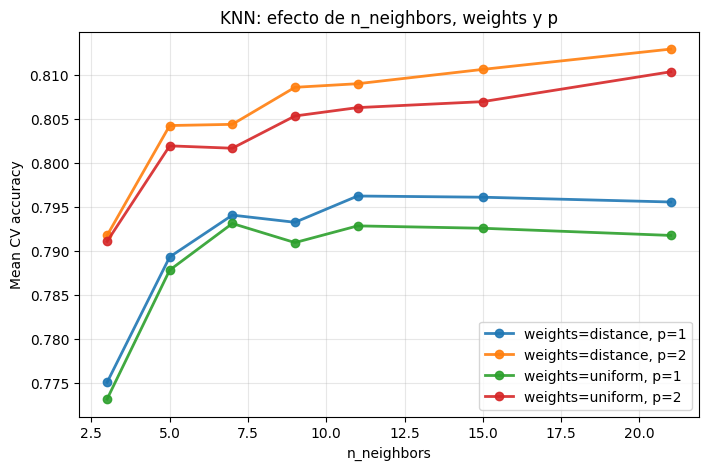

,n_neighbors,weights,p,mean_test_score
25,21,distance,2,0.812891
21,15,distance,2,0.810585
27,21,uniform,2,0.810314
17,11,distance,2,0.808957
13,9,distance,2,0.808549
23,15,uniform,2,0.806922
19,11,uniform,2,0.806243
15,9,uniform,2,0.805293
9,7,distance,2,0.804343
5,5,distance,2,0.804207


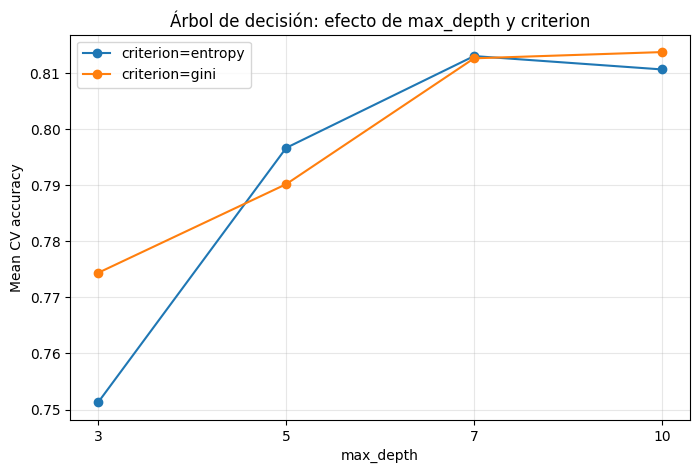

,max_depth,criterion,mean_test_score
1,10,gini,0.813738
6,7,entropy,0.813026
7,7,gini,0.812627
0,10,entropy,0.810644
4,5,entropy,0.796658
5,5,gini,0.790188
3,3,gini,0.774388
2,3,entropy,0.751325


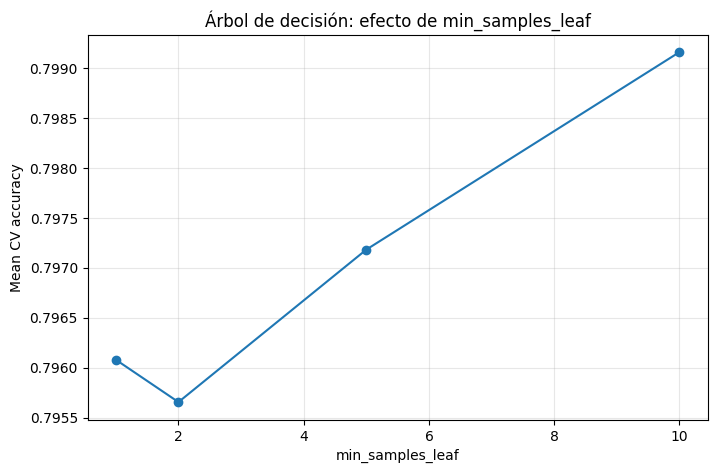

,min_samples_leaf,mean_test_score
0,1,0.796079
1,2,0.795655
2,5,0.797181
3,10,0.799159


In [61]:
print("--- 4.2.d EFECTO DE LOS HIPERPARÁMETROS ---")

# ==========
# KNN
# ==========
knn_plot_df = cv_results_knn.copy()

knn_plot_df["n_neighbors"] = knn_plot_df["param_clasificador__n_neighbors"].astype(int)
knn_plot_df["weights"] = knn_plot_df["param_clasificador__weights"].astype(str)
knn_plot_df["p"] = knn_plot_df["param_clasificador__p"].astype(int)

# Accuracy media agrupada por n_neighbors, weights y p
knn_grouped = (
    knn_plot_df
    .groupby(["n_neighbors", "weights", "p"], as_index=False)["mean_test_score"]
    .mean()
)

plt.figure(figsize=(8, 5))
for (weights, p), subdf in knn_grouped.groupby(["weights", "p"]):
    subdf = subdf.sort_values(by="n_neighbors")
    
    estilo = "-" 
    
    plt.plot(
        subdf["n_neighbors"],
        subdf["mean_test_score"],
        marker="o",
        linestyle=estilo,
        linewidth=2,
        alpha=0.9,
        label=f"weights={weights}, p={p}"
    )

plt.xlabel("n_neighbors")
plt.ylabel("Mean CV accuracy")
plt.title("KNN: efecto de n_neighbors, weights y p")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(knn_grouped.sort_values(by="mean_test_score", ascending=False).head(10))


# ==========
# TREE
# ==========
tree_plot_df = cv_results_tree.copy()

tree_plot_df["criterion"] = tree_plot_df["param_clasificador__criterion"].astype(str)
tree_plot_df["max_depth"] = tree_plot_df["param_clasificador__max_depth"].astype(str)
tree_plot_df["min_samples_leaf"] = tree_plot_df["param_clasificador__min_samples_leaf"].astype(int)

# Accuracy media agrupada por max_depth y criterion
tree_grouped_depth = (
    tree_plot_df
    .groupby(["max_depth", "criterion"], as_index=False)["mean_test_score"]
    .mean()
)

# Orden manual para max_depth
orden_depth = ["3", "5", "7", "10", "None"]
tree_grouped_depth["max_depth"] = pd.Categorical(
    tree_grouped_depth["max_depth"],
    categories=orden_depth,
    ordered=True
)
tree_grouped_depth = tree_grouped_depth.sort_values(by="max_depth")

plt.figure(figsize=(8, 5))
for criterion, subdf in tree_grouped_depth.groupby("criterion"):
    plt.plot(
        subdf["max_depth"].astype(str),
        subdf["mean_test_score"],
        marker="o",
        label=f"criterion={criterion}"
    )

plt.xlabel("max_depth")
plt.ylabel("Mean CV accuracy")
plt.title("Árbol de decisión: efecto de max_depth y criterion")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(tree_grouped_depth.sort_values(by="mean_test_score", ascending=False).head(10))


# ==========
# EXTRA OPCIONAL: min_samples_leaf
# ==========
tree_grouped_leaf = (
    tree_plot_df
    .groupby("min_samples_leaf", as_index=False)["mean_test_score"]
    .mean()
    .sort_values(by="min_samples_leaf")
)

plt.figure(figsize=(8, 5))
plt.plot(
    tree_grouped_leaf["min_samples_leaf"],
    tree_grouped_leaf["mean_test_score"],
    marker="o"
)
plt.xlabel("min_samples_leaf")
plt.ylabel("Mean CV accuracy")
plt.title("Árbol de decisión: efecto de min_samples_leaf")
plt.grid(True, alpha=0.3)
plt.show()

display(tree_grouped_leaf)

**Interpretación de los gráficos**

En **KNN** se observa que los mejores resultados aparecen cuando se utiliza distancia Euclídea (`p = 2`) y ponderación por distancia (`weights = 'distance'`). Además, el rendimiento mejora al aumentar el número de vecinos, siendo los valores altos, especialmente entre **11 y 21**, los que ofrecen mejores resultados. Esto sugiere que, en este problema, KNN se beneficia de decisiones más suavizadas y menos sensibles al ruido local.

En **árboles de decisión**, la profundidad máxima tiene un efecto claro sobre el rendimiento. Los árboles demasiado poco profundos, como los de profundidad 3 o 5, se quedan cortos y rinden peor, mientras que valores alrededor de **10** ofrecen los mejores resultados. Por tanto, el problema parece necesitar árboles con cierta complejidad, aunque no completamente descontrolados.

También se aprecia que introducir regularización mediante `min_samples_leaf` y `min_samples_split` ayuda a mejorar la generalización. En conjunto, los resultados indican que el mejor árbol no es el más simple, pero tampoco uno sin restricciones.

## Conclusiones de los métodos básicos

Para cerrar esta sección, comparamos el rendimiento de los modelos básicos estudiados: `DummyClassifier`, KNN por defecto, árbol por defecto, KNN ajustado y árbol ajustado.

La comparación se realiza utilizando la `accuracy` media obtenida en la evaluación interna y el tiempo medio de entrenamiento. A partir de esta tabla podemos responder a las preguntas clave del apartado: qué método funciona mejor, cuánto cuesta computacionalmente, si realmente mejoran frente a un modelo trivial y si el ajuste de hiperparámetros compensa.

In [62]:
print("--- 4.3 COMPARACIÓN FINAL DE MÉTODOS BÁSICOS ---")

# Por seguridad
NIA = 100495927
columnas_numericas = X_train.select_dtypes(include=['int32', 'int64', 'float64']).columns.tolist()
columnas_categoricas = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Pipeline Dummy
preprocessor_dummy = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

pipeline_dummy = Pipeline(steps=[
    ('preprocesamiento', preprocessor_dummy),
    ('clasificador', DummyClassifier(strategy='most_frequent'))
])

# Pipeline KNN por defecto
preprocessor_knn_default = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

pipeline_knn_default = Pipeline(steps=[
    ('preprocesamiento', preprocessor_knn_default),
    ('clasificador', KNeighborsClassifier())
])

# Pipeline Tree por defecto
preprocessor_tree_default = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', columnas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), columnas_categoricas)
    ]
)

pipeline_tree_default = Pipeline(steps=[
    ('preprocesamiento', preprocessor_tree_default),
    ('clasificador', DecisionTreeClassifier(random_state=NIA))
])

# Evaluación de modelos por defecto y dummy
res_dummy = cross_validate(
    pipeline_dummy, X_train, y_train,
    cv=cv, scoring='accuracy', n_jobs=-1
)

res_knn_default = cross_validate(
    pipeline_knn_default, X_train, y_train,
    cv=cv, scoring='accuracy', n_jobs=-1
)

res_tree_default = cross_validate(
    pipeline_tree_default, X_train, y_train,
    cv=cv, scoring='accuracy', n_jobs=-1
)

# Tabla final
tabla_final_basicos = pd.DataFrame({
    'Modelo': [
        'DummyClassifier',
        'KNN por defecto',
        'Decision Tree por defecto',
        'KNN ajustado (HPO)',
        'Decision Tree ajustado (HPO)'
    ],
    'CV accuracy media': [
        res_dummy['test_score'].mean(),
        res_knn_default['test_score'].mean(),
        res_tree_default['test_score'].mean(),
        grid_knn.best_score_,
        grid_tree.best_score_
    ],
    'Desv. típica CV': [
        res_dummy['test_score'].std(),
        res_knn_default['test_score'].std(),
        res_tree_default['test_score'].std(),
        cv_results_knn.loc[grid_knn.best_index_, 'std_test_score'],
        cv_results_tree.loc[grid_tree.best_index_, 'std_test_score']
    ],
    'Tiempo medio fit (s)': [
        res_dummy['fit_time'].mean(),
        res_knn_default['fit_time'].mean(),
        res_tree_default['fit_time'].mean(),
        cv_results_knn.loc[grid_knn.best_index_, 'mean_fit_time'],
        cv_results_tree.loc[grid_tree.best_index_, 'mean_fit_time']
    ]
}).sort_values('CV accuracy media', ascending=False)

display(tabla_final_basicos)

# Resumen automático para ayudar a redactar conclusiones
mejor_modelo = tabla_final_basicos.iloc[0]
peor_tiempo = tabla_final_basicos.sort_values('Tiempo medio fit (s)', ascending=False).iloc[0]
mejor_dummy = tabla_final_basicos[tabla_final_basicos['Modelo'] == 'DummyClassifier'].iloc[0]
knn_default_acc = tabla_final_basicos[tabla_final_basicos['Modelo'] == 'KNN por defecto']['CV accuracy media'].values[0]
knn_hpo_acc = tabla_final_basicos[tabla_final_basicos['Modelo'] == 'KNN ajustado (HPO)']['CV accuracy media'].values[0]
tree_default_acc = tabla_final_basicos[tabla_final_basicos['Modelo'] == 'Decision Tree por defecto']['CV accuracy media'].values[0]
tree_hpo_acc = tabla_final_basicos[tabla_final_basicos['Modelo'] == 'Decision Tree ajustado (HPO)']['CV accuracy media'].values[0]

print("Mejor modelo en accuracy:", mejor_modelo['Modelo'])
print("Accuracy media del mejor modelo:", round(mejor_modelo['CV accuracy media'], 4))
print("Modelo con mayor coste de entrenamiento:", peor_tiempo['Modelo'])
print("Tiempo medio de fit:", round(peor_tiempo['Tiempo medio fit (s)'], 4), "s")
print("Accuracy del DummyClassifier:", round(mejor_dummy['CV accuracy media'], 4))
print("Mejora KNN tras HPO:", round(knn_hpo_acc - knn_default_acc, 4))
print("Mejora Tree tras HPO:", round(tree_hpo_acc - tree_default_acc, 4))

--- 4.3 COMPARACIÓN FINAL DE MÉTODOS BÁSICOS ---


,Modelo,CV accuracy media,Desv. típica CV,Tiempo medio fit (s)
4,Decision Tree ajustado (HPO),0.822930,0.005373,0.236673
3,KNN ajustado (HPO),0.812891,0.009257,0.056340
1,KNN por defecto,0.801901,0.005784,0.034933
2,Decision Tree por defecto,0.788738,0.000335,0.125034
0,DummyClassifier,0.525509,0.000101,0.036896


Mejor modelo en accuracy: Decision Tree ajustado (HPO)
Accuracy media del mejor modelo: 0.8229
Modelo con mayor coste de entrenamiento: Decision Tree ajustado (HPO)
Tiempo medio de fit: 0.2367 s
Accuracy del DummyClassifier: 0.5255
Mejora KNN tras HPO: 0.011
Mejora Tree tras HPO: 0.0342


**Conclusiones finales**

El mejor método básico ha sido el **árbol de decisión ajustado**, con una `accuracy` media de aproximadamente **0.8232**, superando tanto al KNN ajustado (**0.8106**) como a las versiones por defecto de ambos modelos.

Además, todos los modelos entrenados mejoran claramente al `DummyClassifier`, que se queda en torno a **0.5255**, por lo que podemos concluir que los métodos estudiados están capturando estructura real del problema y no solo reproduciendo la clase mayoritaria.

En cuanto al ajuste de hiperparámetros, en **KNN** la mejora respecto al valor por defecto existe, pero es pequeña, pasando de **0.8016** a **0.8106**. En cambio, en **árboles de decisión** la mejora es mucho más clara, ya que se pasa de **0.7894** a **0.8232**.

Desde el punto de vista computacional, el tiempo medio de entrenamiento de las mejores configuraciones sigue siendo bajo, pero el coste total del proceso de búsqueda sí aumenta de forma notable, especialmente en KNN. Aun así, en el caso de los árboles este coste adicional queda más justificado, porque la mejora en rendimiento es bastante mayor.

En resumen, dentro de los métodos básicos, la opción más sólida para este problema es el **árbol de decisión ajustado**.

# Modelos lineales y SVMs

En este apartado evaluaremos modelos lineales (`LogisticRegression`) y Máquinas de Vectores de Soporte (`SVC`). Dado que estos algoritmos basan sus cálculos en distancias y regularización, es estrictamente necesario escalar las variables numéricas, por lo que reutilizaremos el `StandardScaler` seleccionado en apartados anteriores.

Procederemos directamente a la optimización de hiperparámetros (HPO) utilizando `GridSearchCV` con **3-Fold CV** para obtener la mejor configuración, estimar su rendimiento interno (`best_score_`) y medir el tiempo computacional requerido.

Además, aprovecharemos la interpretabilidad inherente de los modelos lineales para extraer los **pesos** (coeficientes) asignados a cada característica, lo que nos permitirá identificar qué variables son las más determinantes a la hora de predecir la suscripción de depósito.

In [63]:
warnings.filterwarnings("ignore")

print("--- MODELOS LINEALES Y SVM: VALORES POR DEFECTO + HPO ---")

# 1) Preprocesador común
preprocessor_lineal = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

# 2) Evaluación con hiperparámetros por omisión
modelos_base = {
    "Regresión Logística": Pipeline([
        ("preprocesamiento", preprocessor_lineal),
        ("modelo", LogisticRegression(solver="liblinear", random_state=NIA, max_iter=1000))
    ]),
    "SVM (Support Vector Machine)": Pipeline([
        ("preprocesamiento", preprocessor_lineal),
        ("modelo", SVC(random_state=NIA))
    ])
}

resultados_base = []

for nombre, pipeline_modelo in modelos_base.items():
    print(f"-> Evaluación por defecto de {nombre}...")

    inicio = time.time()
    cv_results = cross_validate(
        pipeline_modelo,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )
    tiempo_total = time.time() - inicio

    resultados_base.append({
        "Modelo": nombre,
        "Accuracy media por defecto": round(cv_results["test_score"].mean(), 4),
        "Tiempo por defecto (s)": round(tiempo_total, 4)
    })

df_resultados_base_lineales = pd.DataFrame(resultados_base)

print("\nResultados con hiperparámetros por omisión:")
display(df_resultados_base_lineales)

# 3) HPO de modelos lineales y SVM
configuraciones_hpo = {
    "Regresión Logística": {
        "pipeline": Pipeline([
            ("preprocesamiento", preprocessor_lineal),
            ("modelo", LogisticRegression(solver="liblinear", random_state=NIA, max_iter=1000))
        ]),
        "parametros": {
            "modelo__C": [0.01, 0.1, 1, 10],
            "modelo__penalty": ["l1", "l2"]
        }
    },
    "SVM (Support Vector Machine)": {
        "pipeline": Pipeline([
            ("preprocesamiento", preprocessor_lineal),
            ("modelo", SVC(random_state=NIA))
        ]),
        "parametros": {
            "modelo__C": [0.1, 1, 10],
            "modelo__kernel": ["linear", "rbf"]
        }
    }
}

resultados_hpo = []
mejores_modelos = {}

for nombre, config in configuraciones_hpo.items():
    print(f"-> HPO de {nombre}...")

    grid_search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["parametros"],
        scoring="accuracy",
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    inicio = time.time()
    grid_search.fit(X_train, y_train)
    tiempo_hpo = time.time() - inicio

    resultados_hpo.append({
        "Modelo": nombre,
        "Mejor CV accuracy": round(grid_search.best_score_, 4),
        "Tiempo HPO (s)": round(tiempo_hpo, 4),
        "Mejores parámetros": str(grid_search.best_params_)
    })

    mejores_modelos[nombre] = grid_search.best_estimator_

df_resultados_hpo_lineales = pd.DataFrame(resultados_hpo)

print("\nResultados tras ajuste de hiperparámetros:")
display(df_resultados_hpo_lineales)

# 4) Comparación final dentro de esta sección
df_comparacion_lineales = df_resultados_base_lineales.merge(
    df_resultados_hpo_lineales,
    on="Modelo",
    how="left"
)

df_comparacion_lineales["Mejora de accuracy"] = (
    df_comparacion_lineales["Mejor CV accuracy"] - df_comparacion_lineales["Accuracy media por defecto"]
).round(4)

print("\nComparación final: valores por defecto vs HPO")
display(df_comparacion_lineales)

--- MODELOS LINEALES Y SVM: VALORES POR DEFECTO + HPO ---
-> Evaluación por defecto de Regresión Logística...
-> Evaluación por defecto de SVM (Support Vector Machine)...

Resultados con hiperparámetros por omisión:


,Modelo,Accuracy media por defecto,Tiempo por defecto (s)
0,Regresión Logística,0.8326,0.1659
1,SVM (Support Vector Machine),0.8537,2.5719


-> HPO de Regresión Logística...
-> HPO de SVM (Support Vector Machine)...

Resultados tras ajuste de hiperparámetros:


,Modelo,Mejor CV accuracy,Tiempo HPO (s),Mejores parámetros
0,Regresión Logística,0.8332,1.7456,"{'modelo__C': 1, 'modelo__penalty': 'l1'}"
1,SVM (Support Vector Machine),0.8537,21.4440,"{'modelo__C': 1, 'modelo__kernel': 'rbf'}"



Comparación final: valores por defecto vs HPO


,Modelo,Accuracy media por defecto,Tiempo por defecto (s),Mejor CV accuracy,Tiempo HPO (s),Mejores parámetros,Mejora de accuracy
0,Regresión Logística,0.8326,0.1659,0.8332,1.7456,"{'modelo__C': 1, 'modelo__penalty': 'l1'}",0.0006
1,SVM (Support Vector Machine),0.8537,2.5719,0.8537,21.4440,"{'modelo__C': 1, 'modelo__kernel': 'rbf'}",0.0000


## Interpretabilidad: Importancia de las Variables

A diferencia de los modelos más complejos o de "caja negra" (como un SVM con kernel no lineal), la Regresión Logística nos ofrece una gran **interpretabilidad matemática**. Los coeficientes (o pesos) que el algoritmo asigna a cada característica nos indican directamente su importancia relativa para la predicción.

A continuación, vamos a extraer los coeficientes del mejor modelo de Regresión Logística que ha encontrado nuestro `GridSearchCV`. Ordenaremos estos pesos por su valor absoluto para descubrir el "Top 10" de variables más influyentes. Esto nos permitirá comprobar si la lógica matemática del modelo lineal coincide con las reglas de negocio que descubrimos visualmente en el árbol de decisión (por ejemplo el gran impacto de `duration` o muestra variable preprocesada `contactado_antes`).

In [64]:
#5 Extraer la importancia de las variables del mejor modelo lineal
print("--- IMPORTANCIA DE VARIABLES DEL MEJOR MODELO LINEAL ---")

#Sacamos el mejor modelo lineal guardado en la celda de código anterior
mejor_logreg = mejores_modelos['Regresión Logística']
coeficientes = mejor_logreg.named_steps['modelo'].coef_[0]

#Extraemos los nombres de las variables igual que hicimos con el árbol
preprocesador_entrenado = mejor_logreg.named_steps['preprocesamiento']
nombres_cat = preprocesador_entrenado.named_transformers_['cat'].get_feature_names_out(columnas_categoricas)
todos_los_nombres = list(columnas_numericas) + list(nombres_cat)

#Creamos un Dataframe para verlo mejor
importancia_df = pd.DataFrame({
    'Variable': todos_los_nombres,
    ' Peso (Coeficiente)': coeficientes,
    'Importancia Absoluta': np.abs(coeficientes)
}).sort_values(by='Importancia Absoluta', ascending=False)

#Mostramos el Top 10
display(importancia_df.head(10))

--- IMPORTANCIA DE VARIABLES DEL MEJOR MODELO LINEAL ---


,Variable,Peso (Coeficiente),Importancia Absoluta
23,marital_None,4.846936,4.846936
19,job_None,4.669154,4.669154
44,month_mar,2.316518,2.316518
51,poutcome_success,2.222244,2.222244
3,duration,1.927428,1.927428
36,contact_unknown,-1.595942,1.595942
39,month_dec,1.459436,1.459436
47,month_oct,1.055315,1.055315
15,job_student,1.029860,1.029860
41,month_jan,-1.012589,1.012589


## Conclusión

En esta sección ya se ha seguido el flujo completo pedido para los modelos lineales y SVM:

- primero se han evaluado con sus **hiperparámetros por omisión**
- después se ha realizado el **ajuste de hiperparámetros**
- finalmente se han comparado **rendimiento** y **coste computacional**

A partir de las tablas anteriores, la comparación debe centrarse en dos preguntas:

1. **¿Cuánto mejora realmente la Accuracy tras el HPO?**
2. **¿Compensa esa mejora el tiempo adicional de entrenamiento?**

Esto permite decidir con más criterio si merece la pena elegir un modelo más costoso computacionalmente o si una alternativa más simple ya ofrece un rendimiento suficientemente competitivo.

Además, la Regresión Logística aporta una ventaja adicional importante: su **interpretabilidad**, ya que permite identificar de forma directa qué variables tienen mayor peso en la decisión del modelo.

# 6) Resultados y modelo final

En esta sección cerramos el flujo completo de la práctica. A partir de los resultados obtenidos en los apartados anteriores, ahora toca:

1. seleccionar la mejor alternativa usando únicamente la **evaluación inner**,
2. estimar su rendimiento futuro con la **evaluación outer** sobre el conjunto de **test**,
3. complementar esa evaluación con una **matriz de confusión**,
4. reentrenar el modelo final con todos los datos etiquetados,
5. guardar el modelo final y generar las predicciones del conjunto de competición.

Es importante respetar este orden. El conjunto de test no debe usarse para elegir el modelo, sino solo para estimar una vez su capacidad de generalización. Después de esa estimación outer, ya sí entrenaremos el modelo definitivo con todos los datos disponibles.

In [65]:
print("--- 6.1 SELECCIÓN DEL MEJOR MODELO USANDO SOLO EVALUACIÓN INNER ---")

# ==========
# 1) Reconstruimos las alternativas por defecto para poder tener también
# el objeto estimador disponible en caso de que alguna de ellas gane.
# ==========
preprocessor_scaled_default = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

preprocessor_tree_default = ColumnTransformer(
    transformers=[
        ("num", "passthrough", columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

pipeline_dummy_default = Pipeline(steps=[
    ("preprocesamiento", preprocessor_tree_default),
    ("clasificador", DummyClassifier(strategy="prior"))
])

pipeline_knn_default = Pipeline(steps=[
    ("preprocesamiento", preprocessor_scaled_default),
    ("clasificador", KNeighborsClassifier())
])

pipeline_tree_default = Pipeline(steps=[
    ("preprocesamiento", preprocessor_tree_default),
    ("clasificador", DecisionTreeClassifier(random_state=NIA))
])

pipeline_logreg_default = Pipeline(steps=[
    ("preprocesamiento", preprocessor_scaled_default),
    ("modelo", LogisticRegression(
        solver="liblinear",
        random_state=NIA,
        max_iter=1000
    ))
])

pipeline_svm_default = Pipeline(steps=[
    ("preprocesamiento", preprocessor_scaled_default),
    ("modelo", SVC(random_state=NIA))
])

# ==========
# 2) Recuperamos los resultados ya calculados en secciones anteriores.
# La selección final se hará por Accuracy inner.
# ==========
fila_knn_default = df_resultados_knn.loc[
    df_resultados_knn["Escalador"] == "StandardScaler"
].iloc[0]

fila_dummy = df_resumen_2a.loc[
    df_resumen_2a["Modelo"] == "Dummy Classifier (Baseline)"
].iloc[0]

fila_tree_default = df_resumen_2a.loc[
    df_resumen_2a["Modelo"] == "Decision Tree (Por defecto)"
].iloc[0]

fila_logreg_default = df_resultados_base_lineales.loc[
    df_resultados_base_lineales["Modelo"] == "Regresión Logística"
].iloc[0]

fila_svm_default = df_resultados_base_lineales.loc[
    df_resultados_base_lineales["Modelo"] == "SVM (Support Vector Machine)"
].iloc[0]

fila_logreg_hpo = df_resultados_hpo_lineales.loc[
    df_resultados_hpo_lineales["Modelo"] == "Regresión Logística"
].iloc[0]

fila_svm_hpo = df_resultados_hpo_lineales.loc[
    df_resultados_hpo_lineales["Modelo"] == "SVM (Support Vector Machine)"
].iloc[0]

resumen_global_modelos = pd.DataFrame([
    {
        "Modelo": "Dummy Classifier",
        "Tipo": "Por defecto",
        "Accuracy inner (CV)": round(float(fila_dummy["Accuracy Media"]), 4),
        "Coste computacional reportado (s)": round(float(fila_dummy["Tiempo Total (s)"]), 4),
        "Parámetros": "Por defecto"
    },
    {
        "Modelo": "KNN",
        "Tipo": "Por defecto",
        "Accuracy inner (CV)": round(float(fila_knn_default["Accuracy Media"]), 4),
        "Coste computacional reportado (s)": round(float(fila_knn_default["Tiempo Total (s)"]), 4),
        "Parámetros": "Por defecto con StandardScaler"
    },
    {
        "Modelo": "Decision Tree",
        "Tipo": "Por defecto",
        "Accuracy inner (CV)": round(float(fila_tree_default["Accuracy Media"]), 4),
        "Coste computacional reportado (s)": round(float(fila_tree_default["Tiempo Total (s)"]), 4),
        "Parámetros": "Por defecto"
    },
    {
        "Modelo": "Regresión Logística",
        "Tipo": "Por defecto",
        "Accuracy inner (CV)": round(float(fila_logreg_default["Accuracy media por defecto"]), 4),
        "Coste computacional reportado (s)": round(float(fila_logreg_default["Tiempo por defecto (s)"]), 4),
        "Parámetros": "Por defecto"
    },
    {
        "Modelo": "SVM",
        "Tipo": "Por defecto",
        "Accuracy inner (CV)": round(float(fila_svm_default["Accuracy media por defecto"]), 4),
        "Coste computacional reportado (s)": round(float(fila_svm_default["Tiempo por defecto (s)"]), 4),
        "Parámetros": "Por defecto"
    },
    {
        "Modelo": "KNN",
        "Tipo": "Ajustado (HPO)",
        "Accuracy inner (CV)": round(float(resumen_knn_hpo["Best CV accuracy"].iloc[0]), 4),
        "Coste computacional reportado (s)": round(float(resumen_knn_hpo["Tiempo total HPO (s)"].iloc[0]), 4),
        "Parámetros": resumen_knn_hpo["Best params"].iloc[0]
    },
    {
        "Modelo": "Decision Tree",
        "Tipo": "Ajustado (HPO)",
        "Accuracy inner (CV)": round(float(resumen_tree_hpo["Best CV accuracy"].iloc[0]), 4),
        "Coste computacional reportado (s)": round(float(resumen_tree_hpo["Tiempo total HPO (s)"].iloc[0]), 4),
        "Parámetros": resumen_tree_hpo["Best params"].iloc[0]
    },
    {
        "Modelo": "Regresión Logística",
        "Tipo": "Ajustado (HPO)",
        "Accuracy inner (CV)": round(float(fila_logreg_hpo["Mejor CV accuracy"]), 4),
        "Coste computacional reportado (s)": round(float(fila_logreg_hpo["Tiempo HPO (s)"]), 4),
        "Parámetros": fila_logreg_hpo["Mejores parámetros"]
    },
    {
        "Modelo": "SVM",
        "Tipo": "Ajustado (HPO)",
        "Accuracy inner (CV)": round(float(fila_svm_hpo["Mejor CV accuracy"]), 4),
        "Coste computacional reportado (s)": round(float(fila_svm_hpo["Tiempo HPO (s)"]), 4),
        "Parámetros": fila_svm_hpo["Mejores parámetros"]
    }
])

resumen_global_modelos = resumen_global_modelos.sort_values(
    by="Accuracy inner (CV)",
    ascending=False
).reset_index(drop=True)

display(resumen_global_modelos)

# ==========
# 3) Mapeamos cada fila con su estimador correspondiente.
# Así podemos usar el modelo ganador en las siguientes celdas.
# ==========
estimadores_candidatos = {
    ("Dummy Classifier", "Por defecto"): pipeline_dummy_default,
    ("KNN", "Por defecto"): pipeline_knn_default,
    ("Decision Tree", "Por defecto"): pipeline_tree_default,
    ("Regresión Logística", "Por defecto"): pipeline_logreg_default,
    ("SVM", "Por defecto"): pipeline_svm_default,
    ("KNN", "Ajustado (HPO)"): best_knn_hpo,
    ("Decision Tree", "Ajustado (HPO)"): best_tree_hpo,
    ("Regresión Logística", "Ajustado (HPO)"): mejores_modelos["Regresión Logística"],
    ("SVM", "Ajustado (HPO)"): mejores_modelos["SVM (Support Vector Machine)"]
}

modelo_mejor_nombre = resumen_global_modelos.loc[0, "Modelo"]
modelo_mejor_tipo = resumen_global_modelos.loc[0, "Tipo"]
accuracy_inner_mejor = resumen_global_modelos.loc[0, "Accuracy inner (CV)"]

mejor_estimador_seleccionado = estimadores_candidatos[(modelo_mejor_nombre, modelo_mejor_tipo)]

print(f"Mejor alternativa según la evaluación inner: {modelo_mejor_nombre} [{modelo_mejor_tipo}]")
print(f"Accuracy media en validación cruzada: {accuracy_inner_mejor:.4f}")

--- 6.1 SELECCIÓN DEL MEJOR MODELO USANDO SOLO EVALUACIÓN INNER ---


,Modelo,Tipo,Accuracy inner (CV),Coste computacional reportado (s),Parámetros
0,SVM,Por defecto,0.8537,2.5719,Por defecto
1,SVM,Ajustado (HPO),0.8537,21.4440,"{'modelo__C': 1, 'modelo__kernel': 'rbf'}"
2,Regresión Logística,Ajustado (HPO),0.8332,1.7456,"{'modelo__C': 1, 'modelo__penalty': 'l1'}"
3,Regresión Logística,Por defecto,0.8326,0.1659,Por defecto
4,Decision Tree,Ajustado (HPO),0.8229,15.6868,"{'clasificador__criterion': 'gini', 'clasifica..."
5,KNN,Ajustado (HPO),0.8129,39.4415,"{'clasificador__n_neighbors': 21, 'clasificado..."
6,KNN,Por defecto,0.8019,2.5159,Por defecto con StandardScaler
7,Decision Tree,Por defecto,0.7887,0.2288,Por defecto
8,Dummy Classifier,Por defecto,0.5255,0.1460,Por defecto


Mejor alternativa según la evaluación inner: SVM [Por defecto]
Accuracy media en validación cruzada: 0.8537


La tabla anterior reúne en un único resumen las alternativas evaluadas a lo largo de la práctica. La selección del modelo final debe hacerse **solo** con la `Accuracy inner (CV)`, ya que el conjunto de test sigue reservado y todavía no debe intervenir en la toma de decisiones.

El coste computacional se muestra como criterio secundario para justificar la decisión. Aqui podemos ver que nuestro primer lugar aun teniendo un Inner Accuracy identico al segundo puesto, el coste computacional es mucho menor lo cual lo hace el claro ganador.

El modelo que aparece en primera posición es el que pasará a la evaluación outer sobre test.

## Evaluación outer del mejor modelo sobre test

Una vez seleccionado el mejor modelo usando únicamente la evaluación inner, ahora lo entrenamos con `X_train` e `y_train` y lo evaluamos **una sola vez** sobre `X_test` e `y_test`.

Esta evaluación outer proporciona una estimación del rendimiento futuro del modelo. Además de la métrica principal de la práctica, incluimos la **matriz de confusión** para analizar con más detalle el tipo de errores cometidos.

--- 6.2 EVALUACIÓN OUTER EN EL CONJUNTO DE TEST ---


,Modelo evaluado,Accuracy en test,Nº instancias train,Nº instancias test
0,SVM [Por defecto],0.8446,7370,3630


,Predicho: no,Predicho: yes
Real: no,1585,322
Real: yes,242,1481


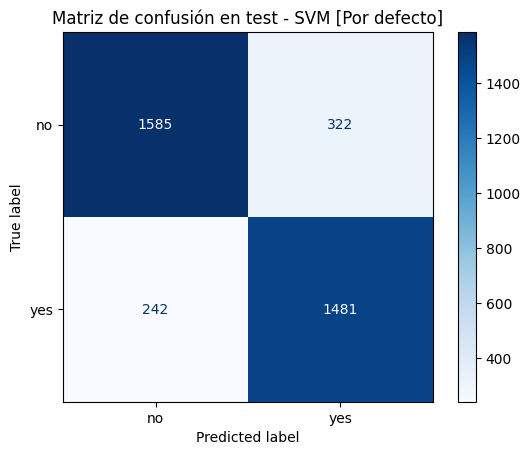

In [66]:
print("--- 6.2 EVALUACIÓN OUTER EN EL CONJUNTO DE TEST ---")

# Clonamos el estimador para entrenarlo limpiamente solo con train
modelo_outer = clone(mejor_estimador_seleccionado)
modelo_outer.fit(X_train, y_train)

# Predicciones sobre test
y_pred_test = modelo_outer.predict(X_test)

# Métrica principal en test
accuracy_test = accuracy_score(y_test, y_pred_test)

resumen_test = pd.DataFrame({
    "Modelo evaluado": [f"{modelo_mejor_nombre} [{modelo_mejor_tipo}]"],
    "Accuracy en test": [round(accuracy_test, 4)],
    "Nº instancias train": [X_train.shape[0]],
    "Nº instancias test": [X_test.shape[0]]
})

display(resumen_test)

# Matriz de confusión en tabla
cm = confusion_matrix(y_test, y_pred_test)
cm_df = pd.DataFrame(
    cm,
    index=["Real: no", "Real: yes"],
    columns=["Predicho: no", "Predicho: yes"]
)

display(cm_df)

# Matriz de confusión en gráfico
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["no", "yes"]
)
disp.plot(values_format="d", cmap="Blues")
plt.title(f"Matriz de confusión en test - {modelo_mejor_nombre} [{modelo_mejor_tipo}]")
plt.grid(False)
plt.show()

La `Accuracy` obtenida en test es la **estimación outer** del rendimiento futuro del modelo. Lo razonable ahora es compararla con la `Accuracy inner (CV)` usada para seleccionar la mejor alternativa.

Si ambas cifras son parecidas, eso sugiere que el modelo generaliza de forma estable. Si en test cae mucho respecto a validación cruzada, habría indicios de sobreajuste. En nuestro caso podemes ver valores muy similares de Accuracy obtenida en el test a la Inner Accuracy lo cual nos indica que el SVM generaliza de forma estable.

La matriz de confusión añade información importante, porque permite ver si el modelo comete más errores al detectar clientes que **sí** contratarían el depósito o al clasificar correctamente a quienes **no** lo harían.

## Entrenamiento del modelo final y guardado

Después de estimar el rendimiento futuro en test, ya podemos entrenar el modelo definitivo usando **todos los datos etiquetados** disponibles. Esto tiene sentido porque, una vez hecha la evaluación outer, interesa aprovechar toda la información posible para construir el modelo que se usará en competición y en el despliegue.

El enunciado menciona `modelo_final.pkl`, pero en la parte de entregables se pide `modelo_final.joblib`. Para evitar problemas en la entrega, hemos decidido guardar el mismo modelo con ambos nombres para asegurar que no haya ningun problema.

In [67]:
print("--- 6.3 ENTRENAMIENTO DEL MODELO FINAL CON TODOS LOS DATOS Y GUARDADO ---")

# Reconstruimos el conjunto etiquetado completo
X_full = df.drop(columns=["deposit"])
y_full = df["deposit"].map({"no": 0, "yes": 1})

# Entrenamos el modelo final con todos los datos disponibles
modelo_final = clone(mejor_estimador_seleccionado)
modelo_final.fit(X_full, y_full)

# Guardamos el modelo con ambos nombres para cubrir lo que pide el enunciado
joblib.dump(modelo_final, "modelo_final.joblib")
joblib.dump(modelo_final, "modelo_final.pkl")

print(f"Modelo final entrenado con {X_full.shape[0]} instancias y {X_full.shape[1]} variables.")
print("Archivos guardados correctamente:")
print("- modelo_final.joblib")
print("- modelo_final.pkl")

--- 6.3 ENTRENAMIENTO DEL MODELO FINAL CON TODOS LOS DATOS Y GUARDADO ---
Modelo final entrenado con 11000 instancias y 16 variables.
Archivos guardados correctamente:
- modelo_final.joblib
- modelo_final.pkl


Con esta celda ya queda generado el modelo definitivo listo para usarse fuera del notebook. Es importante que lo que se guarda sea la **pipeline completa**, incluyendo el preprocesamiento, para que después pueda recibir datos nuevos sin necesidad de aplicar transformaciones manuales externas.

## Predicciones para el conjunto de competición

En esta parte final se intenta localizar automáticamente el fichero de competición dentro de la carpeta `Datos`. Se aplica el mismo tratamiento especial de `pdays` utilizado durante el entrenamiento y se generan las predicciones finales en `predicciones.csv`.

Si el fichero de competición no está presente en el proyecto, la celda no debe fallar de forma abrupta. En su lugar, mostrará un mensaje claro indicando qué archivo falta y qué ficheros `.pkl` hay realmente disponibles en la carpeta. Esto aunque no lo pide el enunciado hemos decidido hacerlo para asegurar consistencia en el proyecto.

In [68]:
print("--- 6.4 PREDICCIONES PARA EL CONJUNTO DE COMPETICIÓN ---")

# ==========
# 1) Localización robusta del fichero de competición
# ==========
ruta_train = Path(ruta_archivo)
carpeta_datos = ruta_train.parent
sufijo = ruta_train.stem.replace("bank_", "")

candidatos = [
    carpeta_datos / f"bank_competition_{sufijo}.pkl",
    carpeta_datos / "bank_competition.pkl",
    carpeta_datos / f"competition_{sufijo}.pkl",
]

ficheros_pkl_disponibles = sorted(carpeta_datos.glob("*.pkl"))
ruta_competicion = next((ruta for ruta in candidatos if ruta.exists()), None)

if ruta_competicion is None:
    print("No se ha encontrado el fichero de competición.")
    print(f"Carpeta revisada: {carpeta_datos.resolve()}")
    print("\nFicheros .pkl disponibles actualmente:")
    
    if ficheros_pkl_disponibles:
        for fichero in ficheros_pkl_disponibles:
            print(f"- {fichero.name}")
    else:
        print("- No hay ningún fichero .pkl en la carpeta Datos")
    
    print("\nConclusión:")
    print("Falta añadir el dataset de competición al proyecto.")
    print("Cuando lo copies a la carpeta 'Datos', vuelve a ejecutar esta celda.")
    
else:
    print(f"Fichero de competición encontrado: {ruta_competicion}")

    # ==========
    # 2) Carga del dataset de competición
    # ==========
    df_competicion = pd.read_pickle(ruta_competicion)
    print(f"Número de instancias en competición: {df_competicion.shape[0]}")
    print(f"Número de variables originales en competición: {df_competicion.shape[1]}")

    # ==========
    # 3) Mismo tratamiento especial de pdays que en entrenamiento
    # ==========
    if "pdays" in df_competicion.columns:
        df_competicion["contactado_antes"] = (df_competicion["pdays"] != -1).astype(int)
        df_competicion = df_competicion.drop(columns=["pdays"])
        print("Preprocesado aplicado: 'pdays' transformada en 'contactado_antes' y eliminada la columna original.")
    else:
        print("Aviso: la columna 'pdays' no aparece en el fichero de competición.")

    # ==========
    # 4) Alineación exacta de columnas con el entrenamiento
    # ==========
    columnas_esperadas = X_full.columns.tolist()

    faltan = [col for col in columnas_esperadas if col not in df_competicion.columns]
    sobran = [col for col in df_competicion.columns if col not in columnas_esperadas]

    if faltan:
        print("\nError de estructura:")
        print(f"Faltan columnas en el dataset de competición: {faltan}")
    else:
        if sobran:
            print("\nAviso:")
            print(f"Hay columnas extra en competición y no se usarán: {sobran}")

        X_competicion = df_competicion.reindex(columns=columnas_esperadas)

        # ==========
        # 5) Predicción con el modelo final ya entrenado
        # ==========
        pred_comp_num = modelo_final.predict(X_competicion)
        pred_comp_labels = pd.Series(pred_comp_num).map({0: "no", 1: "yes"})

        predicciones_competicion = pd.DataFrame({
            "deposit": pred_comp_labels
        })

        # ==========
        # 6) Guardado del fichero requerido
        # ==========
        predicciones_competicion.to_csv("predicciones.csv", index=False)

        print("\nPredicciones generadas correctamente.")
        print(f"Número de predicciones generadas: {len(predicciones_competicion)}")
        print("Archivo guardado: predicciones.csv")

        print("\nDistribución de predicciones:")
        display(
            predicciones_competicion["deposit"]
            .value_counts()
            .rename_axis("Clase")
            .reset_index(name="Frecuencia")
        )

        print("\nPrimeras filas del fichero generado:")
        display(predicciones_competicion.head())

--- 6.4 PREDICCIONES PARA EL CONJUNTO DE COMPETICIÓN ---
Fichero de competición encontrado: Datos/bank_competition.pkl
Número de instancias en competición: 162
Número de variables originales en competición: 16
Preprocesado aplicado: 'pdays' transformada en 'contactado_antes' y eliminada la columna original.

Predicciones generadas correctamente.
Número de predicciones generadas: 162
Archivo guardado: predicciones.csv

Distribución de predicciones:


,Clase,Frecuencia
0,no,93
1,yes,69



Primeras filas del fichero generado:


,deposit
0,no
1,no
2,no
3,yes
4,yes


Si esta celda se ejecuta correctamente, el apartado 4 del enunciado queda cerrado dentro de este notebook: ya se ha seleccionado el mejor modelo, se ha estimado su rendimiento futuro con test, se ha entrenado el modelo definitivo y se han generado las predicciones del conjunto de competición.

# 7) Tarea de elección abierta

Como tarea adicional, se va a probar un modelo no trabajado en las secciones anteriores: **Random Forest** (`RandomForestClassifier`).

La elección de este método se justifica por varios motivos:

- es un modelo basado en árboles, por lo que guarda relación con parte del trabajo ya realizado,
- suele mejorar la estabilidad y capacidad predictiva respecto a un único árbol de decisión,
- permite seguir utilizando el mismo esquema general de evaluación ya definido en la práctica,
- y resulta interesante comprobar si una técnica de ensamblado puede aportar una mejora real en este problema.

El objetivo de esta sección no es rehacer toda la práctica, sino comprobar si este modelo adicional ofrece un rendimiento competitivo y si merece la pena frente a las alternativas ya evaluadas.

## Evaluación inicial de Random Forest con hiperparámetros por defecto

En primer lugar, se evaluará un `RandomForestClassifier` con hiperparámetros por omisión utilizando la misma estrategia de evaluación interna empleada en el resto de la práctica.

Como se trata de un modelo basado en árboles, no necesita escalado de variables numéricas. Sin embargo, las variables categóricas sí deben codificarse, por lo que se reutilizará un `ColumnTransformer` con paso directo para numéricas y `OneHotEncoder` para categóricas.

Además de la `Accuracy` media en validación cruzada, también se medirá el tiempo de ejecución para poder comparar el coste computacional con el de otros métodos.

In [69]:
print("--- 7.1 RANDOM FOREST POR DEFECTO ---")

# Preprocesado adecuado para modelos basados en árboles
preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", columnas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), columnas_categoricas)
    ]
)

pipeline_rf_default = Pipeline(steps=[
    ("preprocesamiento", preprocessor_rf),
    ("modelo", RandomForestClassifier(random_state=NIA, n_jobs=-1))
])

inicio = time.time()
cv_rf_default = cross_validate(
    pipeline_rf_default,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)
tiempo_rf_default = time.time() - inicio

df_rf_default = pd.DataFrame([{
    "Modelo": "Random Forest",
    "Tipo": "Por defecto",
    "Accuracy media (CV)": round(cv_rf_default["test_score"].mean(), 4),
    "Tiempo total (s)": round(tiempo_rf_default, 4)
}])

display(df_rf_default)

--- 7.1 RANDOM FOREST POR DEFECTO ---


,Modelo,Tipo,Accuracy media (CV),Tiempo total (s)
0,Random Forest,Por defecto,0.8525,1.042


La tabla anterior muestra el rendimiento inicial de Random Forest sin ajuste de hiperparámetros.

Este resultado sirve como punto de partida para comprobar si el modelo ya es competitivo por defecto o si, por el contrario, necesita ajuste para mostrar su potencial. Igual que en apartados anteriores, la comparación debe hacerse teniendo en cuenta tanto el rendimiento como el coste computacional.

In [70]:
print("--- 7.2 RANDOM FOREST CON AJUSTE DE HIPERPARÁMETROS ---")

param_grid_rf = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [None, 10, 20],
    "modelo__min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    estimator=pipeline_rf_default,
    param_grid=param_grid_rf,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True
)

inicio = time.time()
grid_rf.fit(X_train, y_train)
tiempo_rf_hpo = time.time() - inicio

best_rf_hpo = grid_rf.best_estimator_

df_rf_hpo = pd.DataFrame([{
    "Modelo": "Random Forest",
    "Tipo": "Ajustado (HPO)",
    "Mejor Accuracy (CV)": round(grid_rf.best_score_, 4),
    "Tiempo total HPO (s)": round(tiempo_rf_hpo, 4),
    "Mejores parámetros": str(grid_rf.best_params_)
}])

display(df_rf_hpo)

--- 7.2 RANDOM FOREST CON AJUSTE DE HIPERPARÁMETROS ---


,Modelo,Tipo,Mejor Accuracy (CV),Tiempo total HPO (s),Mejores parámetros
0,Random Forest,Ajustado (HPO),0.8525,16.8635,"{'modelo__max_depth': None, 'modelo__min_sampl..."


Aqui podemos ver que el ajuste no produce variacion pero aumenta el tiempo total considerablemente.

## Comparación de Random Forest con el mejor modelo previo

Para valorar el interés real de esta tarea abierta, se comparará Random Forest con la mejor alternativa obtenida anteriormente en la práctica.

La comparación se hará usando la evaluación interna, ya que ese ha sido el criterio general seguido para comparar modelos durante todo el desarrollo del trabajo.

In [71]:
print("--- 7.3 COMPARACIÓN CON EL MEJOR MODELO PREVIO ---")

# Recuperamos el mejor resultado previo de la práctica
mejor_previo = resumen_global_modelos.iloc[0].copy()

accuracy_rf_default = float(df_rf_default.loc[0, "Accuracy media (CV)"])
accuracy_rf_hpo = float(df_rf_hpo.loc[0, "Mejor Accuracy (CV)"])

mejor_rf_accuracy = max(accuracy_rf_default, accuracy_rf_hpo)
mejor_rf_tipo = "Ajustado (HPO)" if accuracy_rf_hpo >= accuracy_rf_default else "Por defecto"

comparacion_tarea_abierta = pd.DataFrame([
    {
        "Alternativa": f"{mejor_previo['Modelo']} [{mejor_previo['Tipo']}]",
        "Accuracy inner (CV)": round(float(mejor_previo["Accuracy inner (CV)"]), 4),
        "Coste computacional (s)": mejor_previo["Coste computacional reportado (s)"]
    },
    {
        "Alternativa": f"Random Forest [{mejor_rf_tipo}]",
        "Accuracy inner (CV)": round(mejor_rf_accuracy, 4),
        "Coste computacional (s)": round(
            tiempo_rf_hpo if mejor_rf_tipo == "Ajustado (HPO)" else tiempo_rf_default,
            4
        )
    }
])

display(comparacion_tarea_abierta)

--- 7.3 COMPARACIÓN CON EL MEJOR MODELO PREVIO ---


,Alternativa,Accuracy inner (CV),Coste computacional (s)
0,SVM [Por defecto],0.8537,2.5719
1,Random Forest [Ajustado (HPO)],0.8525,16.8635


La tabla anterior resume la comparación entre el mejor modelo previo de la práctica y la mejor versión obtenida de Random Forest.

Cabe considerar que Random Forest nos ha mostrado rendimientos identicos con hiperparametros ajustados y deajustados por lo que al hacer max acaba cogiendo el ajustado el cual muestra un coste computacional mayor. Esto ha sido una decisión del equipo. Cabe destacar aquí que si comparamos con el no ajustado vemos un coste computacional de la mitad, lo cual viendo la diferencia de CV (0.0012) lo hace muy atractivo.


## Conclusión de la tarea abierta

Como extensión adicional de la práctica, se ha probado un modelo no trabajado previamente: `RandomForestClassifier`.

Esta elección estaba motivada por su relación con los árboles de decisión y por su capacidad habitual para mejorar la robustez y el rendimiento mediante ensamblado. Tras evaluarlo con la misma estrategia de validación interna utilizada en el resto del trabajo, se puede comparar de forma directa con la mejor alternativa obtenida anteriormente.

Como hemos visto anteriormente Random Forest muestra un CV practicamente idéntico a nuestro SVM mientras que su coste computacional (caso no ajustado) nos da la mitad. Haciendolo mas atractivo que el SVM utilizado.